# Notebook 012 — Quality Control and Catalog Cleaning

## Objective

In the previous notebook, the AI identified two statistical outliers.
Visual inspection showed that both were located on the edge of the Hubble
image, demonstrating that observational effects can influence machine
learning results.

In this notebook we will build the first quality-control pipeline for the
Cosmic Intelligence Lab.

We will:

- Load the astronomical source catalog.
- Identify edge-truncated detections.
- Remove unreliable detections.
- Create a science-ready catalog.
- Compare the cleaned catalog with the original catalog.

This notebook introduces an important concept used in professional
astronomical surveys:

> **Machine learning performs best when trained on carefully curated data.**

Quality control is therefore an essential step before statistical analysis
or machine learning.

In [1]:
# Cell 2 - Import Libraries ===================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, PercentileInterval

plt.rcParams["figure.figsize"] = (10, 10)

In [2]:
# Cell 3 - Load Source Catalog ================================

catalog = Table.read("../data/catalogs/source_catalog.ecsv")

print("=" * 60)
print("Astronomical Source Catalog")
print("=" * 60)

print(f"Number of detected sources : {len(catalog)}")
print(f"Number of catalog columns  : {len(catalog.colnames)}")

Astronomical Source Catalog
Number of detected sources : 95
Number of catalog columns  : 19


In [3]:
# Cell 4 - Load Hubble Image ==================================

image_file = Path(
    "../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits"
)

with fits.open(image_file) as hdul:
    image = hdul["SCI"].data

print("=" * 60)
print("Hubble Image")
print("=" * 60)

print(f"Image size : {image.shape}")
print(f"Data type  : {image.dtype}")

Hubble Image
Image size : (1014, 1014)
Data type  : >f4


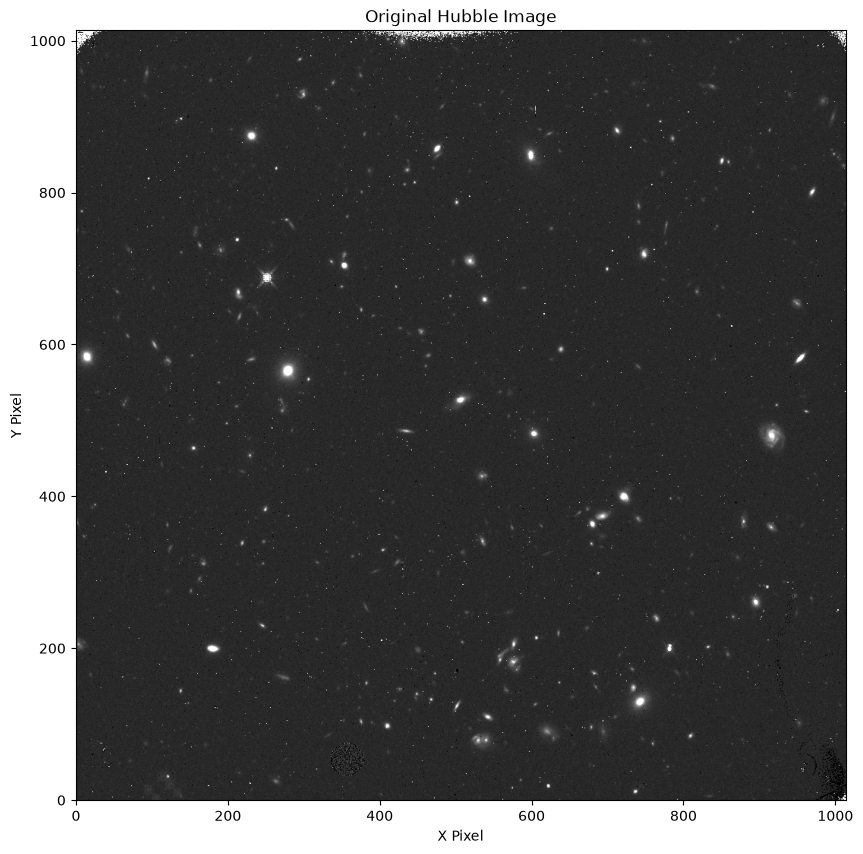

In [4]:
# Cell 5 - Display Hubble Image ===============================

norm = ImageNormalize(
    image,
    interval=PercentileInterval(99.5)
)

plt.imshow(
    image,
    cmap="gray",
    origin="lower",
    norm=norm
)

plt.title("Original Hubble Image")

plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.show()

In [5]:
# Cell 6 - Initial Catalog Statistics =========================

print("=" * 60)
print("Catalog Summary")
print("=" * 60)

print(f"Total detected objects : {len(catalog)}")

print(f"\nMean Flux : {np.mean(catalog['segment_flux']):.2f}")
print(f"Median Flux : {np.median(catalog['segment_flux']):.2f}")

print(f"\nMean Area : {np.mean(catalog['area']):.2f}")
print(f"Median Area : {np.median(catalog['area']):.2f}")

Catalog Summary
Total detected objects : 95

Mean Flux : 188.78
Median Flux : 17.00

Mean Area : 38.21
Median Area : 14.00


In [6]:
# Cell 7 - Identify Edge Sources ===============================

margin = 25  # pixels

edge_mask = (
    (catalog["x_centroid"] < margin) |
    (catalog["x_centroid"] > image.shape[1] - margin) |
    (catalog["y_centroid"] < margin) |
    (catalog["y_centroid"] > image.shape[0] - margin)
)

edge_sources = catalog[edge_mask]

print("=" * 60)
print("Edge Source Detection")
print("=" * 60)

print(f"Margin used          : {margin} pixels")
print(f"Edge sources found   : {len(edge_sources)}")
print(f"Remaining candidates : {len(catalog) - len(edge_sources)}")

Edge Source Detection
Margin used          : 25 pixels
Edge sources found   : 16
Remaining candidates : 79


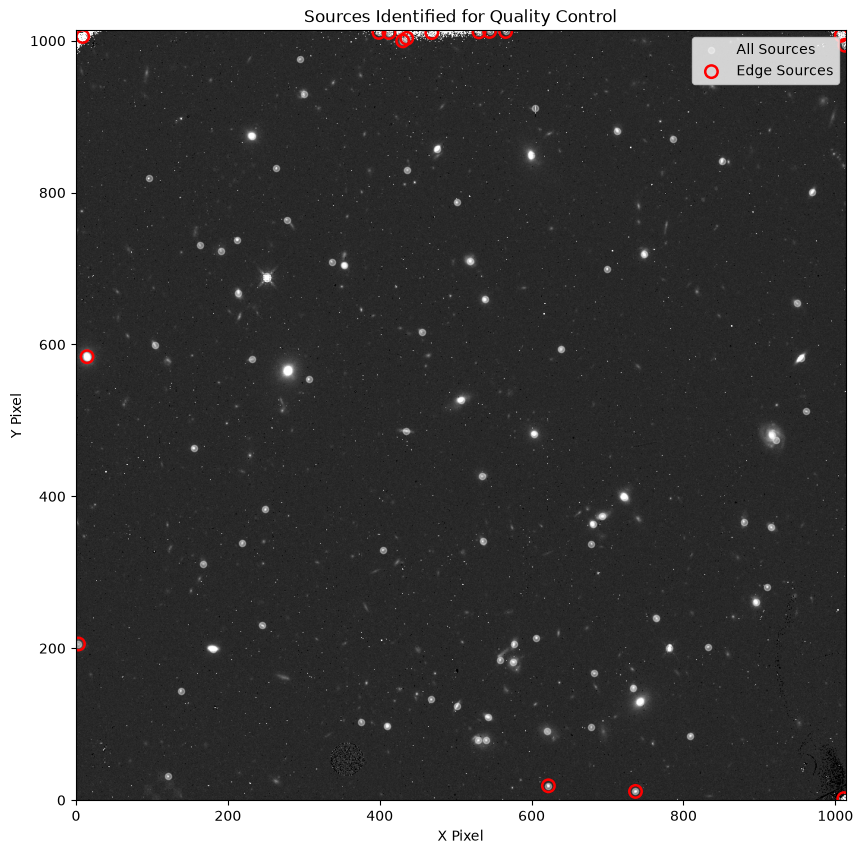

In [7]:
# Cell 8 - Visualize Edge Sources ==============================

plt.figure(figsize=(10, 10))

plt.imshow(
    image,
    cmap="gray",
    origin="lower",
    norm=norm
)

# All detected sources
plt.scatter(
    catalog["x_centroid"],
    catalog["y_centroid"],
    s=20,
    color="white",
    alpha=0.35,
    label="All Sources"
)

# Edge sources
plt.scatter(
    edge_sources["x_centroid"],
    edge_sources["y_centroid"],
    s=80,
    facecolors="none",
    edgecolors="red",
    linewidths=1.8,
    label="Edge Sources"
)

plt.title("Sources Identified for Quality Control")

plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.legend()

plt.show()

In [8]:
# Cell 9 - Create Clean Catalog ================================

clean_catalog = catalog[~edge_mask]

print("=" * 60)
print("Clean Catalog")
print("=" * 60)

print(f"Original catalog : {len(catalog)} objects")
print(f"Clean catalog    : {len(clean_catalog)} objects")
print(f"Objects removed  : {len(catalog) - len(clean_catalog)}")

Clean Catalog
Original catalog : 95 objects
Clean catalog    : 79 objects
Objects removed  : 16


In [9]:
# Cell 10 - Compare Catalog Statistics =========================

print("=" * 65)
print("Original vs Clean Catalog")
print("=" * 65)

print(f"{'Statistic':<25}{'Original':>12}{'Clean':>12}")
print("-" * 49)

print(f"{'Number of Objects':<25}{len(catalog):>12}{len(clean_catalog):>12}")

print(f"{'Mean Flux':<25}"
      f"{np.mean(catalog['segment_flux']):>12.2f}"
      f"{np.mean(clean_catalog['segment_flux']):>12.2f}")

print(f"{'Median Flux':<25}"
      f"{np.median(catalog['segment_flux']):>12.2f}"
      f"{np.median(clean_catalog['segment_flux']):>12.2f}")

print(f"{'Mean Area':<25}"
      f"{np.mean(catalog['area']):>12.2f}"
      f"{np.mean(clean_catalog['area']):>12.2f}")

print(f"{'Median Area':<25}"
      f"{np.median(catalog['area']):>12.2f}"
      f"{np.median(clean_catalog['area']):>12.2f}")

Original vs Clean Catalog
Statistic                    Original       Clean
-------------------------------------------------
Number of Objects                  95          79
Mean Flux                      188.78       58.53
Median Flux                     17.00       11.94
Mean Area                       38.21       28.51
Median Area                     14.00       13.00


In [10]:
# Cell 11 - Save Clean Catalog ================================

output_file = Path("../data/catalogs/clean_source_catalog.ecsv")

clean_catalog.write(
    output_file,
    format="ascii.ecsv",
    overwrite=True
)

print("=" * 60)
print("Catalog Saved")
print("=" * 60)
print(output_file)

Catalog Saved
../data/catalogs/clean_source_catalog.ecsv


## Results

Removing edge-truncated detections produced a substantially cleaner
astronomical catalog.

Although only 16 of the 95 detected sources were removed, those objects
had a disproportionate influence on the statistical properties of the
catalog.

The mean source flux decreased by approximately **69%**, while the mean
source area decreased by approximately **25%**.

These results demonstrate that a small number of extreme detections can
strongly bias statistical analyses and machine learning models.

Quality-control procedures therefore improve the reliability and
interpretability of AI-assisted astronomical studies.

In [11]:
# ============================================================
# Notebook Status
# ============================================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 12_quality_control_and_catalog_cleaning.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 12_quality_control_and_catalog_cleaning.ipynb
Completed : 2026-07-16 12:01
